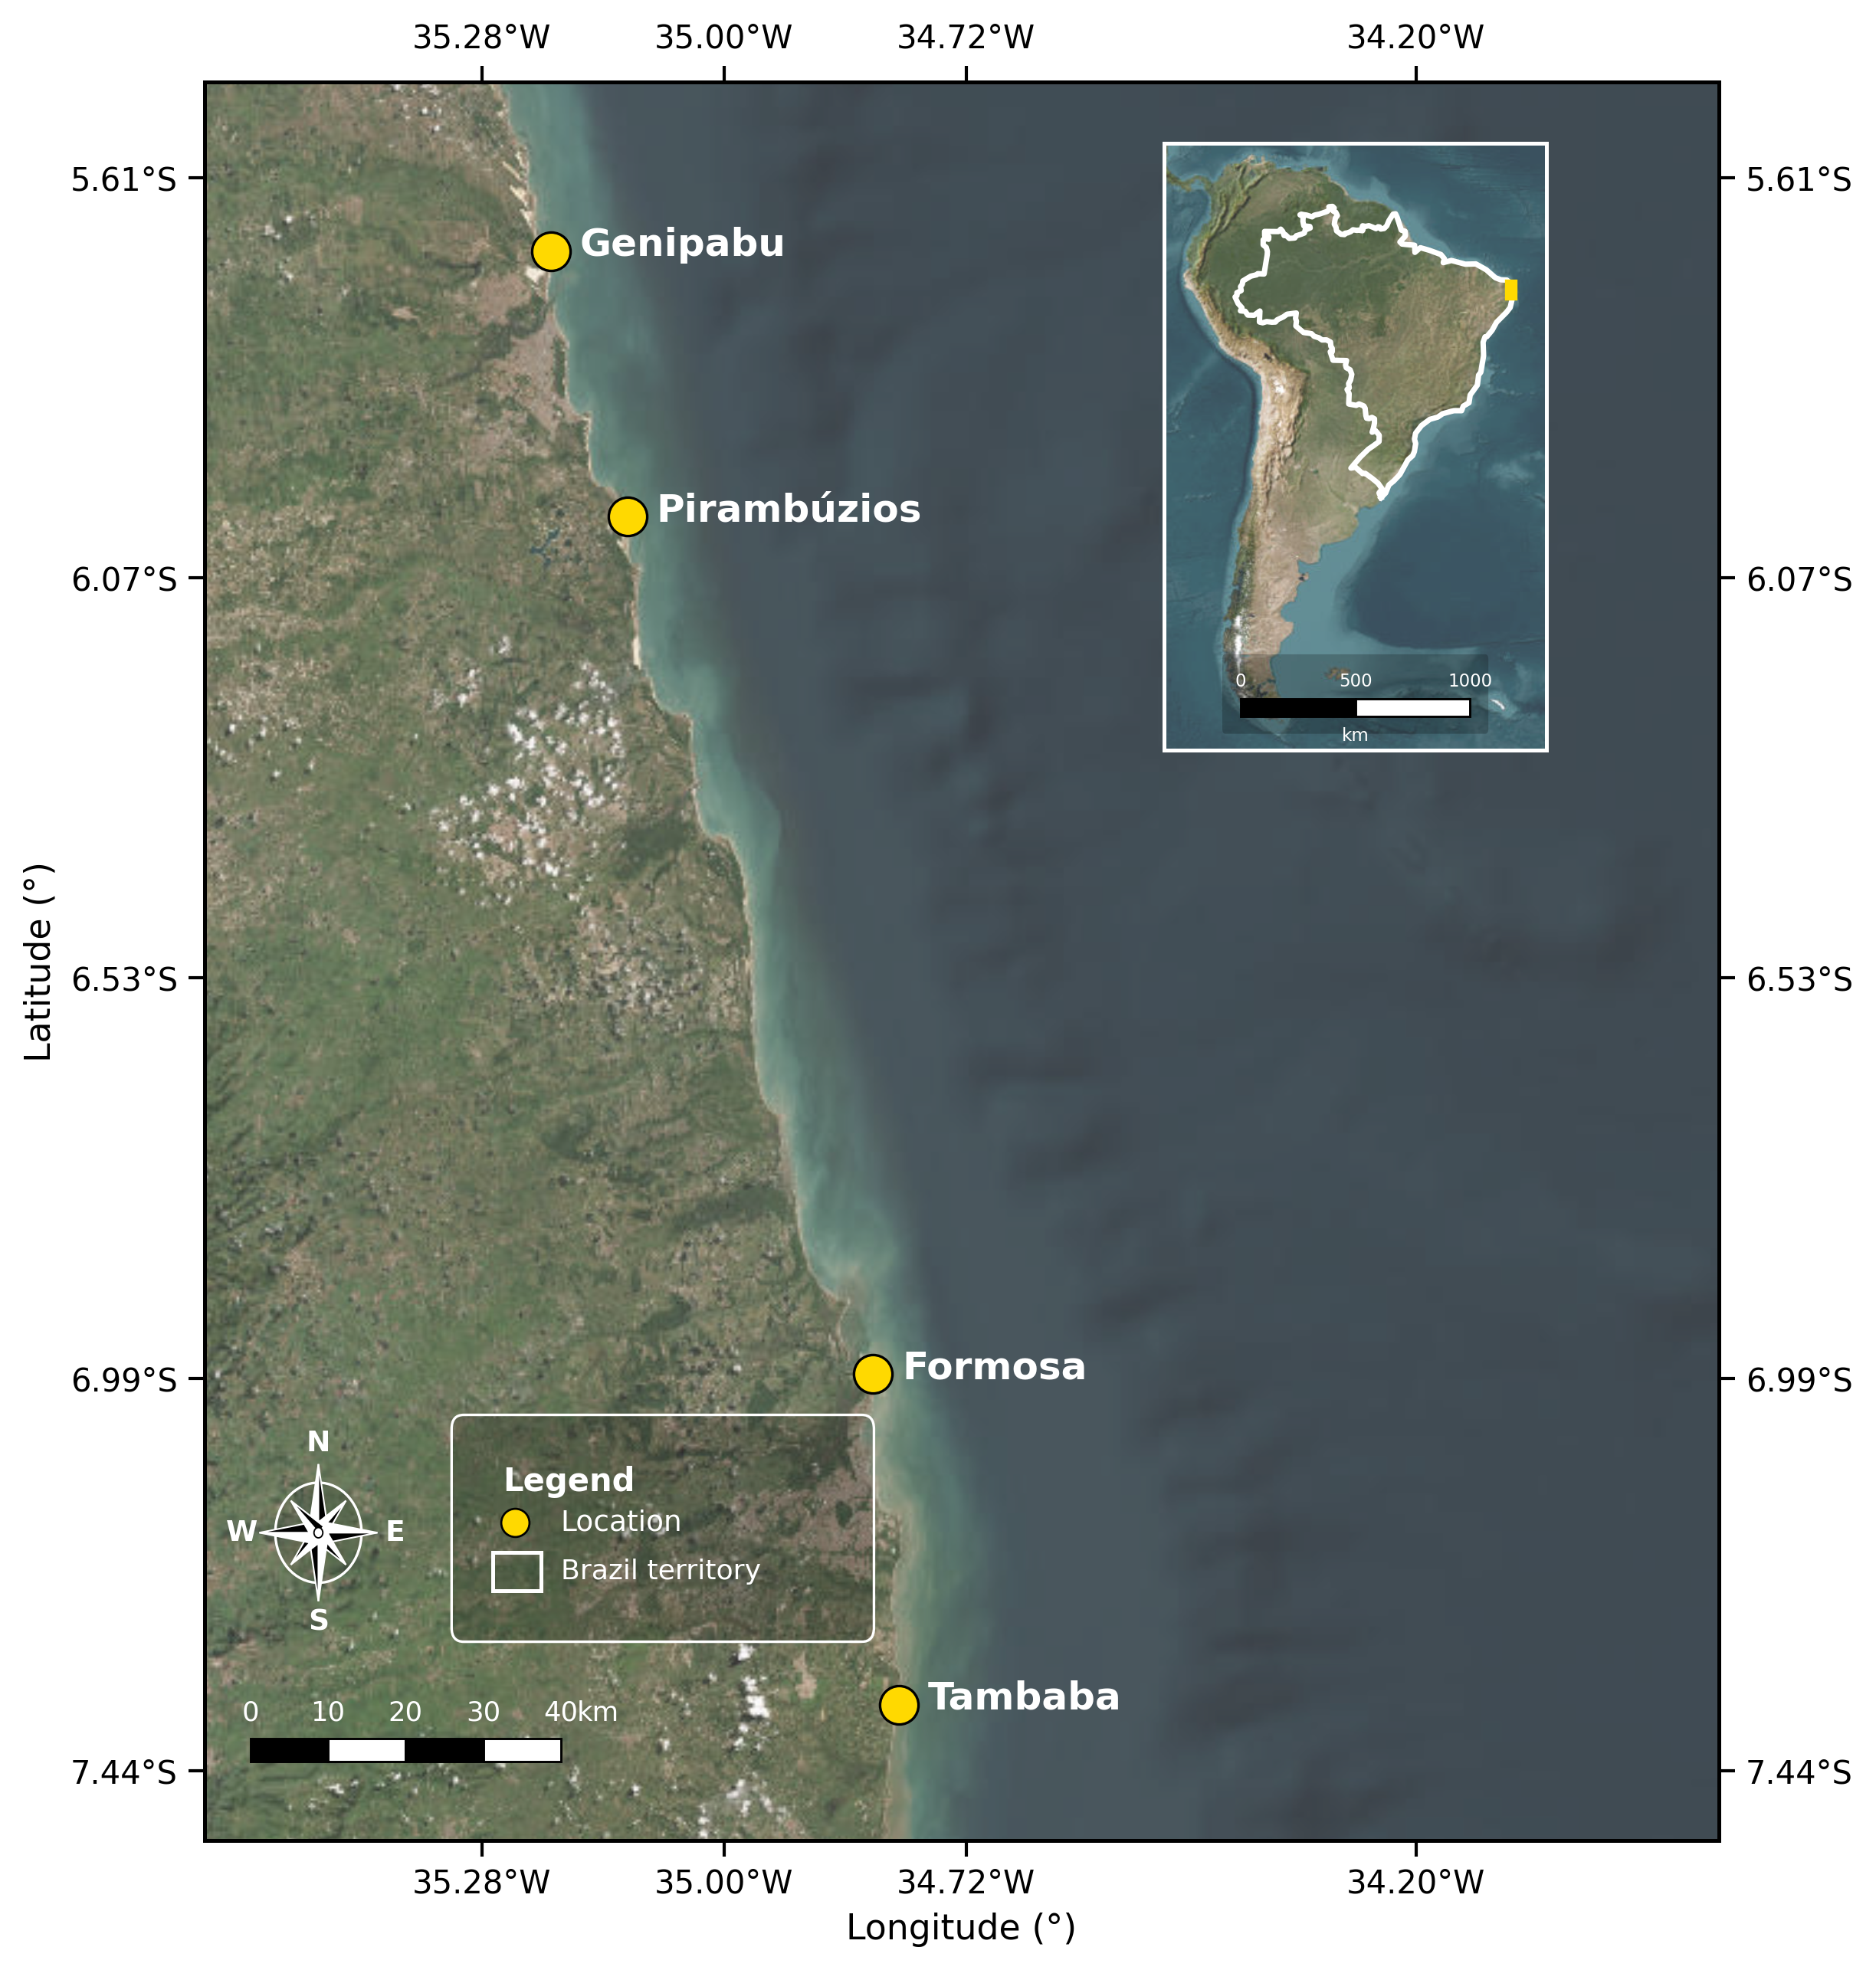

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import cartopy.io.shapereader as shpreader

from matplotlib.patches import Rectangle, Circle, Polygon, FancyBboxPatch
from pyproj import Transformer
from shapely.ops import transform as shapely_transform

sites = {
    "Genipabu": (-35.199984, -5.694830),
    "Pirambúzios": (-35.111394, -5.999948),
    "Formosa": (-34.827411, -6.984957),
    "Tambaba": (-34.797600, -7.364373),
}

lon_min, lon_max = -35.60, -33.85
lat_min, lat_max = -7.52, -5.50

BRIGHTNESS = 0.20
SATURATION = 0.72

wgs84_to_merc = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True
)

geometry_transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True
)

def to_mercator(lon, lat):
    return wgs84_to_merc.transform(lon, lat)

def project_geometry(geometry):
    return shapely_transform(
        geometry_transformer.transform,
        geometry
    )

def soften_basemap(ax, brightness=0.20, saturation=0.72):
    if not ax.images:
        return

    image = ax.images[-1]
    array = np.asarray(image.get_array()).astype(float)

    if array.max() > 1:
        array /= 255.0

    rgb = array[..., :3]

    gray = (
        0.2126 * rgb[..., 0] +
        0.7152 * rgb[..., 1] +
        0.0722 * rgb[..., 2]
    )[..., None]

    rgb = gray + saturation * (rgb - gray)
    rgb = rgb * (1 - brightness) + brightness
    rgb = np.clip(rgb, 0, 1)

    if array.shape[-1] == 4:
        result = np.dstack([rgb, array[..., 3]])
    else:
        result = rgb

    image.set_data(result)

def add_main_scale_bar(
    ax,
    length_km=40,
    pos_rel=(0.03, 0.045),
    height_rel=0.013,
    text_size=8.5
):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    x0 = xmin + pos_rel[0] * (xmax - xmin)
    y0 = ymin + pos_rel[1] * (ymax - ymin)

    total_m = length_km * 1000
    n_segments = 4
    segment = total_m / n_segments
    height = height_rel * (ymax - ymin)

    for i in range(n_segments):
        ax.add_patch(
            Rectangle(
                (x0 + i * segment, y0),
                segment,
                height,
                facecolor="black" if i % 2 == 0 else "white",
                edgecolor="black",
                linewidth=0.7,
                zorder=30
            )
        )

    for i, value in enumerate([0, 10, 20, 30, 40]):
        ax.text(
            x0 + i * segment,
            y0 + height * 1.55,
            str(value),
            color="white",
            fontsize=text_size,
            ha="center",
            va="bottom",
            zorder=31
        )

    ax.text(
        x0 + total_m + segment * 0.20,
        y0 + height * 1.55,
        "km",
        color="white",
        fontsize=text_size,
        ha="left",
        va="bottom",
        zorder=31
    )

def add_inset_scale_bar(ax):
    total_width = 0.60
    x0 = (1.0 - total_width) / 2

    y0 = 0.055
    height = 0.030
    segment_width = total_width / 2
    scale_font = 5.5

    background_margin = 0.04
    background_x = x0 - background_margin
    background_width = total_width + 2 * background_margin

    ax.add_patch(
        FancyBboxPatch(
            (background_x, y0 - 0.020),
            background_width,
            0.115,
            transform=ax.transAxes,
            boxstyle="round,pad=0.008,rounding_size=0.008",
            facecolor=(0, 0, 0, 0.22),
            edgecolor="none",
            zorder=78
        )
    )

    for i in range(2):
        ax.add_patch(
            Rectangle(
                (x0 + i * segment_width, y0),
                segment_width,
                height,
                transform=ax.transAxes,
                facecolor="black" if i == 0 else "white",
                edgecolor="black",
                linewidth=0.7,
                zorder=80
            )
        )

    label_y = y0 + height + 0.014

    ax.text(
        x0,
        label_y,
        "0",
        transform=ax.transAxes,
        color="white",
        fontsize=scale_font,
        ha="center",
        va="bottom",
        zorder=81
    )

    ax.text(
        x0 + segment_width,
        label_y,
        "500",
        transform=ax.transAxes,
        color="white",
        fontsize=scale_font,
        ha="center",
        va="bottom",
        zorder=81
    )

    ax.text(
        x0 + total_width,
        label_y,
        "1000",
        transform=ax.transAxes,
        color="white",
        fontsize=scale_font,
        ha="center",
        va="bottom",
        zorder=81
    )

    ax.text(
        x0 + total_width / 2,
        y0 - 0.016,
        "km",
        transform=ax.transAxes,
        color="white",
        fontsize=scale_font,
        ha="center",
        va="top",
        zorder=81
    )

def add_compass_rose(
    ax,
    center=(0.075, 0.175),
    radius=0.039
):
    cx, cy = center

    ax.add_patch(
        Circle(
            (cx, cy),
            radius * 0.73,
            transform=ax.transAxes,
            facecolor=(0, 0, 0, 0.10),
            edgecolor="white",
            linewidth=0.8,
            zorder=40
        )
    )

    for i, angle in enumerate(np.arange(0, 360, 45)):
        theta = np.deg2rad(90 - angle)

        if i % 2 == 0:
            r_tip = radius
            r_side = radius * 0.17
        else:
            r_tip = radius * 0.66
            r_side = radius * 0.13

        dx = np.cos(theta)
        dy = np.sin(theta)

        px = -dy
        py = dx

        tip = (
            cx + r_tip * dx,
            cy + r_tip * dy
        )

        left = (
            cx + r_side * px,
            cy + r_side * py
        )

        right = (
            cx - r_side * px,
            cy - r_side * py
        )

        ax.add_patch(
            Polygon(
                [(cx, cy), left, tip],
                closed=True,
                transform=ax.transAxes,
                facecolor="white",
                edgecolor="white",
                linewidth=0.50,
                zorder=42
            )
        )

        ax.add_patch(
            Polygon(
                [(cx, cy), tip, right],
                closed=True,
                transform=ax.transAxes,
                facecolor="black",
                edgecolor="white",
                linewidth=0.50,
                zorder=42
            )
        )

    ax.add_patch(
        Circle(
            (cx, cy),
            radius * 0.075,
            transform=ax.transAxes,
            facecolor="white",
            edgecolor="black",
            linewidth=0.45,
            zorder=44
        )
    )

    d = radius * 1.30

    labels = {
        "N": (cx, cy + d),
        "S": (cx, cy - d),
        "W": (cx - d, cy),
        "E": (cx + d, cy)
    }

    for label, (x, y) in labels.items():
        ax.text(
            x,
            y,
            label,
            transform=ax.transAxes,
            color="white",
            fontsize=9,
            fontweight="bold",
            ha="center",
            va="center",
            zorder=45
        )

def add_legend_box(
    ax,
    xy=(0.175, 0.125),
    width=0.255,
    height=0.105
):
    x0, y0 = xy

    ax.add_patch(
        FancyBboxPatch(
            (x0, y0),
            width,
            height,
            transform=ax.transAxes,
            boxstyle="round,pad=0.012,rounding_size=0.008",
            facecolor=(0, 0, 0, 0.18),
            edgecolor="white",
            linewidth=0.8,
            zorder=50
        )
    )

    ax.text(
        x0 + 0.022,
        y0 + height - 0.026,
        "Legend",
        transform=ax.transAxes,
        color="white",
        fontsize=10,
        fontweight="bold",
        ha="left",
        va="center",
        zorder=51
    )

    ax.scatter(
        x0 + 0.030,
        y0 + 0.056,
        transform=ax.transAxes,
        s=78,
        c="#FFD900",
        edgecolor="black",
        linewidth=0.65,
        zorder=52
    )

    ax.text(
        x0 + 0.060,
        y0 + 0.056,
        "Location",
        transform=ax.transAxes,
        color="white",
        fontsize=9,
        ha="left",
        va="center",
        zorder=52
    )

    ax.add_patch(
        Rectangle(
            (x0 + 0.015, y0 + 0.017),
            0.032,
            0.022,
            transform=ax.transAxes,
            fill=False,
            edgecolor="white",
            linewidth=1.2,
            zorder=52
        )
    )

    ax.text(
        x0 + 0.060,
        y0 + 0.028,
        "Brazil territory",
        transform=ax.transAxes,
        color="white",
        fontsize=8.7,
        ha="left",
        va="center",
        zorder=52
    )

x_min, y_min = to_mercator(lon_min, lat_min)
x_max, y_max = to_mercator(lon_max, lat_max)

fig, ax = plt.subplots(
    figsize=(15, 9),
    dpi=300
)

ax.set_xlim(
    x_min,
    x_max
)

ax.set_ylim(
    y_min,
    y_max
)

ax.set_aspect("equal")

ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldImagery,
    zoom=9,
    attribution=False
)

soften_basemap(
    ax,
    brightness=BRIGHTNESS,
    saturation=SATURATION
)

for name, (lon, lat) in sites.items():
    x, y = to_mercator(
        lon,
        lat
    )

    ax.scatter(
        x,
        y,
        s=145,
        c="#FFD900",
        edgecolor="black",
        linewidth=0.8,
        zorder=20
    )

    ax.annotate(
        name,
        (x, y),
        xytext=(9, 2),
        textcoords="offset points",
        color="white",
        fontsize=12,
        fontweight="bold",
        ha="left",
        va="center",
        zorder=21
    )

lon_ticks = np.array([
    -35.28,
    -35.00,
    -34.72,
    -34.20
])

lat_ticks = np.array([
    -5.61,
    -6.07,
    -6.53,
    -6.99,
    -7.44
])

x_ticks = [
    to_mercator(lon, -6.5)[0]
    for lon in lon_ticks
]

y_ticks = [
    to_mercator(-35.0, lat)[1]
    for lat in lat_ticks
]

ax.set_xticks(
    x_ticks
)

ax.set_yticks(
    y_ticks
)

ax.set_xticklabels(
    [f"{abs(v):.2f}°W" for v in lon_ticks],
    fontsize=10
)

ax.set_yticklabels(
    [f"{abs(v):.2f}°S" for v in lat_ticks],
    fontsize=10
)

ax.tick_params(
    axis="both",
    direction="out",
    length=5,
    width=1,
    top=True,
    bottom=True,
    left=True,
    right=True,
    labeltop=True,
    labelbottom=True,
    labelleft=True,
    labelright=True
)

ax.set_xlabel(
    "Longitude (°)",
    fontsize=11
)

ax.set_ylabel(
    "Latitude (°)",
    fontsize=11
)

for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color("black")

add_main_scale_bar(
    ax,
    length_km=40,
    pos_rel=(0.03, 0.045),
    height_rel=0.013,
    text_size=8.5
)

add_compass_rose(
    ax,
    center=(0.075, 0.175),
    radius=0.039
)

add_legend_box(
    ax,
    xy=(0.175, 0.125),
    width=0.255,
    height=0.105
)

# South America inset
inset = ax.inset_axes([
    0.525,
    0.620,
    0.470,
    0.345
])

sa_lon_min = -84
sa_lon_max = -30
sa_lat_min = -58
sa_lat_max = 14

sa_xmin, sa_ymin = to_mercator(
    sa_lon_min,
    sa_lat_min
)

sa_xmax, sa_ymax = to_mercator(
    sa_lon_max,
    sa_lat_max
)

inset.set_xlim(
    sa_xmin,
    sa_xmax
)

inset.set_ylim(
    sa_ymin,
    sa_ymax
)

inset.set_aspect("equal")

ctx.add_basemap(
    inset,
    source=ctx.providers.Esri.WorldImagery,
    zoom=3,
    attribution=False
)

soften_basemap(
    inset,
    brightness=BRIGHTNESS,
    saturation=SATURATION
)

countries_file = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

records = list(
    shpreader.Reader(
        countries_file
    ).records()
)

for country in records:
    country_name = country.attributes.get(
        "NAME_LONG",
        country.attributes.get("NAME", "")
    )

    if country_name == "Brazil":
        brazil = project_geometry(
            country.geometry
        )

        if brazil.geom_type == "Polygon":
            polygons = [brazil]
        else:
            polygons = list(
                brazil.geoms
            )

        for polygon in polygons:
            x, y = polygon.exterior.xy

            inset.plot(
                x,
                y,
                color="white",
                linewidth=1.7,
                zorder=50
            )

box_lon_min = -35.45
box_lon_max = -34.55
box_lat_min = -7.55
box_lat_max = -5.55

box_xmin, box_ymin = to_mercator(
    box_lon_min,
    box_lat_min
)

box_xmax, box_ymax = to_mercator(
    box_lon_max,
    box_lat_max
)

inset.add_patch(
    Rectangle(
        (box_xmin, box_ymin),
        box_xmax - box_xmin,
        box_ymax - box_ymin,
        fill=False,
        edgecolor="#FFD900",
        linewidth=2.0,
        zorder=60
    )
)

add_inset_scale_bar(
    inset
)

inset.set_xticks([])
inset.set_yticks([])

for spine in inset.spines.values():
    spine.set_color("white")
    spine.set_linewidth(1.2)

inset.set_facecolor(
    "none"
)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.10,
    top=0.95
)

plt.savefig(
    "sampling_sites_satellite_map_final.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()